In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
REPO_URL = "https://github.com/kabdoullah/plant-disease-classification.git"
if os.path.exists('/content/project/.git'):
    !git -C /content/project pull
else:
    !git clone {REPO_URL} /content/project

!pip install -q timm

import sys
if '/content/project' not in sys.path:
    sys.path.insert(0, '/content/project')

from src import config
from src.utils import set_seed, get_device, count_parameters, file_size_mb
set_seed(config.SEED)
device = get_device()
print("Device :", device, "|", config.NUM_CLASSES, "classes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 699 bytes | 699.00 KiB/s, done.
From https://github.com/kabdoullah/plant-disease-classification
   0e44579..74cc56c  main       -> origin/main
Updating 0e44579..74cc56c
Fast-forward
 src/config.py         | 2 +-
 src/training/train.py | 3 +++
 2 files changed, 4 insertions(+), 1 deletion(-)
Device : cuda | 5 classes


In [2]:
import json
from pathlib import Path

DATA_DIR = "/content/data/tomato5"
if not Path(DATA_DIR).exists():
    !mkdir -p /content/data
    !unzip -q {config.DRIVE_ROOT}/dataset/tomato5.zip -d /content/data
!ls {DATA_DIR}

_subset_info.json	 Tomato___Early_blight	Tomato___Late_blight
Tomato___Bacterial_spot  Tomato___healthy	Tomato___Septoria_leaf_spot


In [3]:
from src.data.loaders import get_dataloaders

splits_file = config.RESULTS_DIR / "splits.json"
saved = json.loads(splits_file.read_text())

assert saved["classes"] == config.CLASSES, "Split incohérent avec config.CLASSES"
splits = {k: saved[k] for k in ("train", "val", "test")}

loaders = get_dataloaders(DATA_DIR, splits)
for name in ("train", "val", "test"):
    print(f"{name:6s} {len(splits[name]):5d} images")

train   1400 images
val      300 images
test     300 images


In [4]:
from src.models.build import build_model
from src.training.train import fit

set_seed(config.SEED)   # remise à zéro : même initialisation de tête

cnn, cnn_params = build_model("cnn")
print("Paramètres totaux    :", f"{count_parameters(cnn):,}")
print("Paramètres entraînables:", f"{count_parameters(cnn, True):,}")

cnn_hist, cnn_best, cnn_time = fit(
    cnn, cnn_params, loaders, device, "cnn", config.MODELS_DIR)

Paramètres totaux    : 11,179,077
Paramètres entraînables: 2,565
Epoch 1/15 | train loss 1.3935 acc 0.4150 | val loss 1.0165 acc 0.6933 | 14.3s  ← meilleur
Epoch 2/15 | train loss 0.9093 acc 0.7236 | val loss 0.7284 acc 0.7933 | 13.5s  ← meilleur
Epoch 3/15 | train loss 0.7159 acc 0.7943 | val loss 0.6304 acc 0.8000 | 13.2s  ← meilleur
Epoch 4/15 | train loss 0.6194 acc 0.8150 | val loss 0.5807 acc 0.8100 | 13.0s  ← meilleur
Epoch 5/15 | train loss 0.5654 acc 0.8286 | val loss 0.5126 acc 0.8233 | 12.9s  ← meilleur
Epoch 6/15 | train loss 0.5001 acc 0.8593 | val loss 0.4947 acc 0.8400 | 13.3s  ← meilleur
Epoch 7/15 | train loss 0.4863 acc 0.8414 | val loss 0.4523 acc 0.8533 | 11.8s  ← meilleur
Epoch 8/15 | train loss 0.4586 acc 0.8514 | val loss 0.4181 acc 0.8767 | 11.6s  ← meilleur
Epoch 9/15 | train loss 0.4374 acc 0.8593 | val loss 0.4201 acc 0.8567 | 13.8s
Epoch 10/15 | train loss 0.4180 acc 0.8664 | val loss 0.4333 acc 0.8600 | 13.1s
Epoch 11/15 | train loss 0.4163 acc 0.8621 | val

In [5]:
set_seed(config.SEED)   # mêmes conditions initiales que le CNN

vit, vit_params = build_model("vit")
print("Paramètres totaux    :", f"{count_parameters(vit):,}")
print("Paramètres entraînables:", f"{count_parameters(vit, True):,}")

vit_hist, vit_best, vit_time = fit(
    vit, vit_params, loaders, device, "vit", config.MODELS_DIR)

Paramètres totaux    : 5,525,381
Paramètres entraînables: 965
Epoch 1/15 | train loss 1.1607 acc 0.5450 | val loss 0.7712 acc 0.7467 | 12.6s  ← meilleur
Epoch 2/15 | train loss 0.6754 acc 0.7657 | val loss 0.5734 acc 0.8067 | 11.6s  ← meilleur
Epoch 3/15 | train loss 0.5601 acc 0.8064 | val loss 0.4834 acc 0.8400 | 12.6s  ← meilleur
Epoch 4/15 | train loss 0.4868 acc 0.8279 | val loss 0.4418 acc 0.8400 | 13.4s
Epoch 5/15 | train loss 0.4107 acc 0.8614 | val loss 0.3905 acc 0.8800 | 13.6s  ← meilleur
Epoch 6/15 | train loss 0.4122 acc 0.8536 | val loss 0.3595 acc 0.8900 | 13.1s  ← meilleur
Epoch 7/15 | train loss 0.3890 acc 0.8607 | val loss 0.3766 acc 0.8600 | 13.4s
Epoch 8/15 | train loss 0.3565 acc 0.8729 | val loss 0.3345 acc 0.8967 | 13.3s  ← meilleur
Epoch 9/15 | train loss 0.3312 acc 0.8907 | val loss 0.3293 acc 0.8900 | 13.5s
Epoch 10/15 | train loss 0.3398 acc 0.8814 | val loss 0.3237 acc 0.8900 | 12.7s
Epoch 11/15 | train loss 0.3286 acc 0.8871 | val loss 0.3083 acc 0.8867 | 1

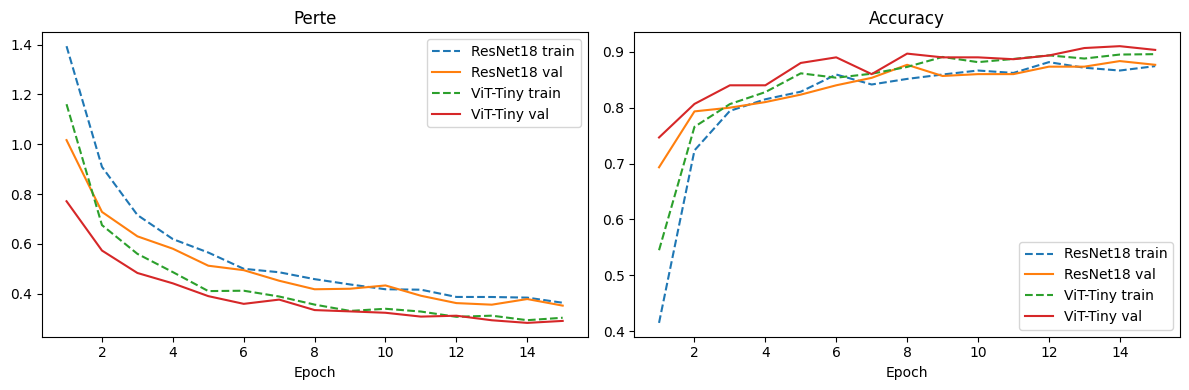

In [6]:
import matplotlib.pyplot as plt

FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(cnn_hist["train_loss"]) + 1)

for h, name in [(cnn_hist, "ResNet18"), (vit_hist, "ViT-Tiny")]:
    axes[0].plot(epochs, h["train_loss"], "--", label=f"{name} train")
    axes[0].plot(epochs, h["val_loss"], "-", label=f"{name} val")
    axes[1].plot(epochs, h["train_acc"], "--", label=f"{name} train")
    axes[1].plot(epochs, h["val_acc"], "-", label=f"{name} val")

axes[0].set_title("Perte"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "courbes_apprentissage.png", dpi=150)
plt.show()

In [7]:
import pandas as pd

summary = pd.DataFrame([
    {"Modèle": "ResNet18",
     "Paramètres totaux": count_parameters(cnn),
     "Paramètres entraînables": count_parameters(cnn, True),
     "Meilleure val acc": round(cnn_best, 4),
     "Temps entraînement (s)": round(cnn_time, 1),
     "Poids (Mo)": round(file_size_mb(config.MODELS_DIR / "cnn_best.pt"), 1)},
    {"Modèle": "ViT-Tiny",
     "Paramètres totaux": count_parameters(vit),
     "Paramètres entraînables": count_parameters(vit, True),
     "Meilleure val acc": round(vit_best, 4),
     "Temps entraînement (s)": round(vit_time, 1),
     "Poids (Mo)": round(file_size_mb(config.MODELS_DIR / "vit_best.pt"), 1)},
])
display(summary)

config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(config.RESULTS_DIR / "training_summary.csv", index=False)

,Modèle,Paramètres totaux,Paramètres entraînables,Meilleure val acc,Temps entraînement (s),Poids (Mo)
0,ResNet18,11179077,2565,0.8833,201.7,42.7
1,ViT-Tiny,5525381,965,0.9100,196.9,21.1
